In [4]:
import torch
import torch.optim as optim
import torch.nn as nn
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__() 
        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,1,padding="same"), # 32,28,28
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2,stride=2), #32,14,14

            nn.Conv2d(32,64,3,1,padding="same"), #64,14,14
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2,stride=2), #64,7,7

        )

        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128,256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256,10),
            nn.Dropout(p=0.3),
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.linear(x)
        return x
    

In [7]:
lr = 0.001
batch_size = 32

In [8]:
training_data = FashionMNIST(r"C:\Users\sarma\OneDrive\Desktop\GITHUB NEW\Git work\Datasets\FashionMNIST",train=True,transform=transforms.ToTensor(),download=True)
testing_data = FashionMNIST(r"C:\Users\sarma\OneDrive\Desktop\GITHUB NEW\Git work\Datasets\FashionMNIST",train=False,transform=transforms.ToTensor(),download=True)

train_loader = DataLoader(training_data,batch_size=batch_size,shuffle=True)
test_loader  = DataLoader(testing_data,batch_size=batch_size)

In [9]:
epochs = 25
model = CNN().to(device)
optimizer = optim.SGD(model.parameters(),lr=lr)
criterion = nn.CrossEntropyLoss()
for epoch in range(epochs):
    total_loss = 0
    for features,labels in train_loader:
        features = features.to(device)
        labels = labels.to(device)

        output = model.forward(features)
        optimizer.zero_grad()

        loss = criterion(output,labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"epoch --> {epoch+1} loss --> {total_loss}")


epoch --> 1 loss --> 2721.0484233498573
epoch --> 2 loss --> 1910.7024024128914
epoch --> 3 loss --> 1703.220968335867
epoch --> 4 loss --> 1586.6576608121395
epoch --> 5 loss --> 1504.5764668285847
epoch --> 6 loss --> 1446.3058859109879
epoch --> 7 loss --> 1394.0595576167107
epoch --> 8 loss --> 1367.9497970193624
epoch --> 9 loss --> 1338.2688377201557
epoch --> 10 loss --> 1307.9253077805042
epoch --> 11 loss --> 1282.51733610034
epoch --> 12 loss --> 1268.1312267184258
epoch --> 13 loss --> 1255.3236158639193
epoch --> 14 loss --> 1231.7855769693851
epoch --> 15 loss --> 1211.225605994463
epoch --> 16 loss --> 1209.6256208270788
epoch --> 17 loss --> 1189.6617376059294
epoch --> 18 loss --> 1178.4758957624435
epoch --> 19 loss --> 1168.0919591635466
epoch --> 20 loss --> 1170.8695829212666
epoch --> 21 loss --> 1146.844985410571
epoch --> 22 loss --> 1138.3544117361307
epoch --> 23 loss --> 1133.44254912436
epoch --> 24 loss --> 1121.350259527564
epoch --> 25 loss --> 1108.690909

In [10]:
model.eval()

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
    (8): Dropout(p=0.3, inplace=False)
  )
)

Accuracy = 0.916, correct = 9160


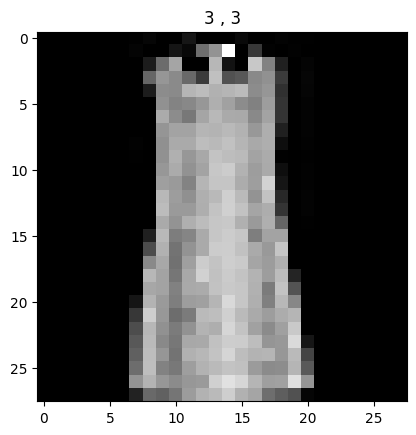

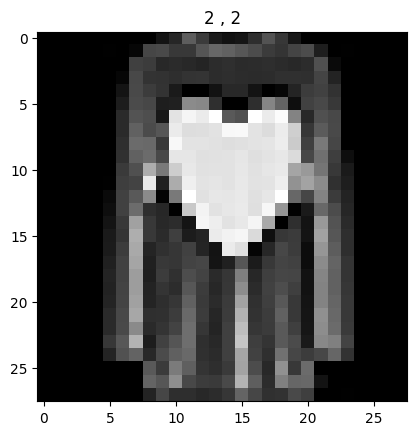

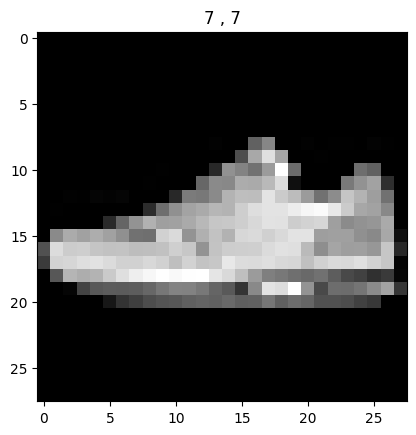

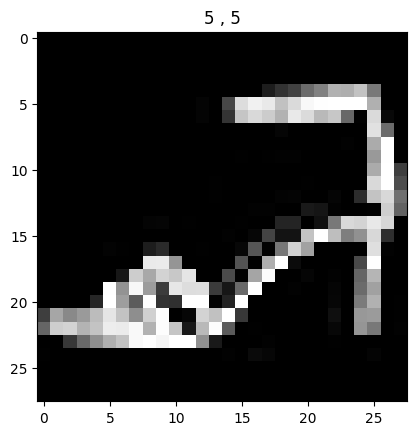

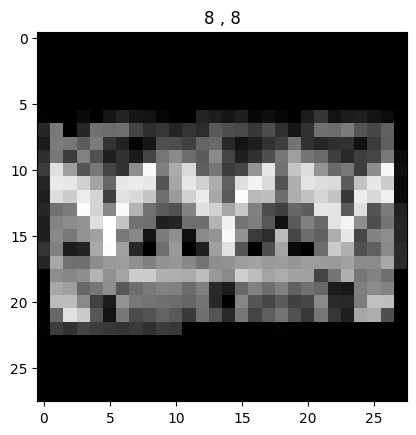

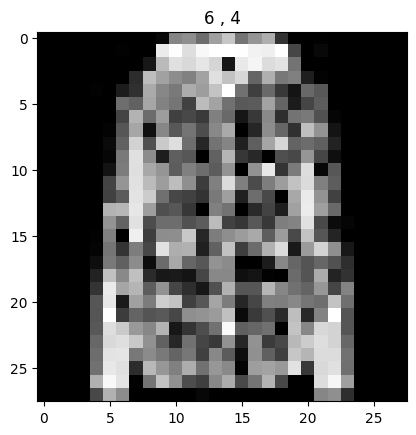

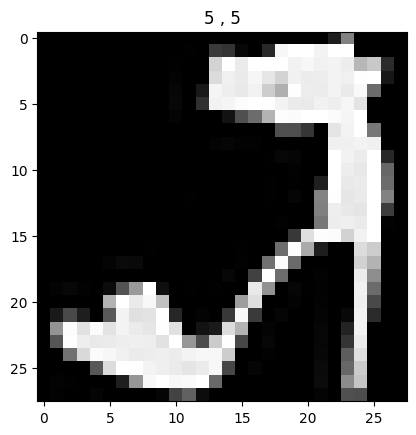

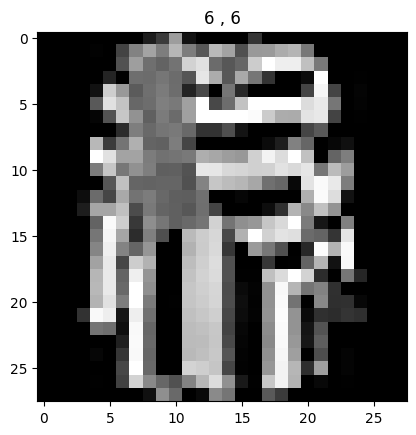

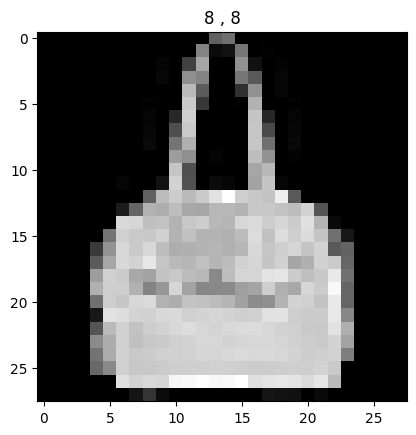

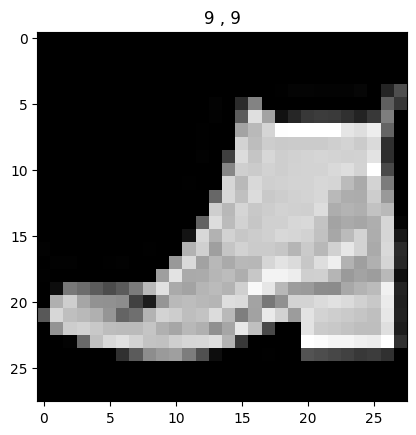

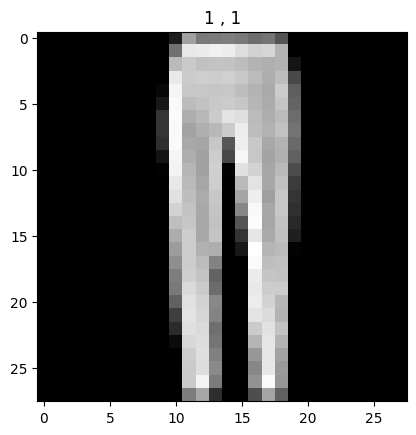

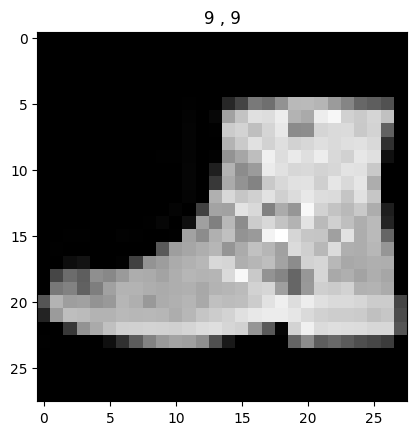

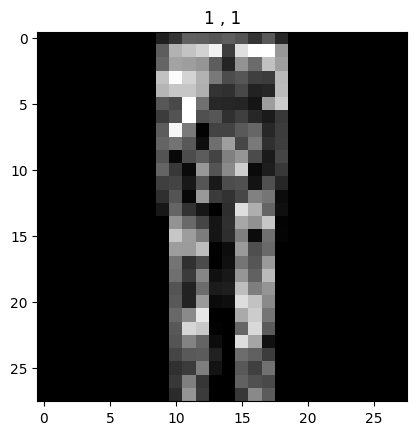

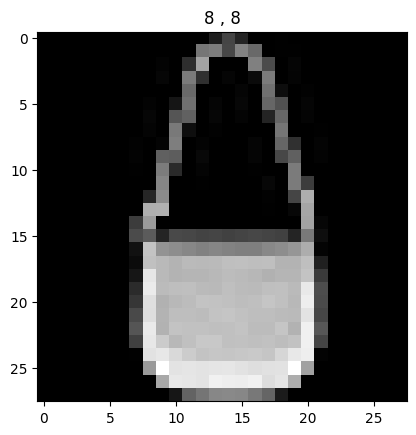

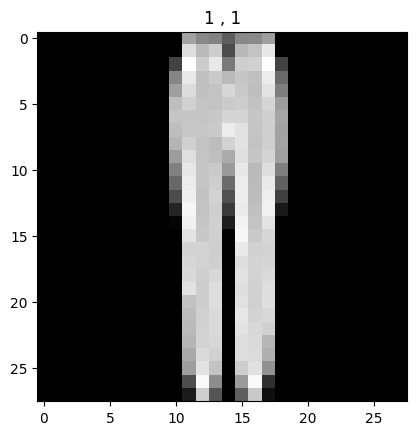

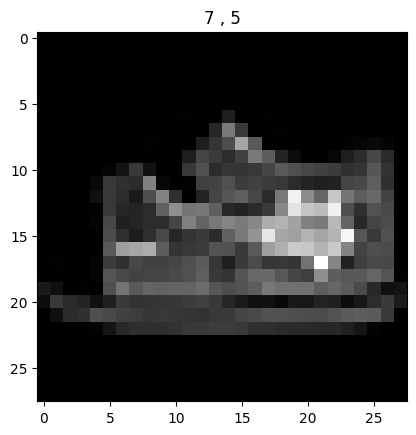

In [16]:
import matplotlib.pyplot as plt
idx = 9
correct = 0
with torch.no_grad():
    for features, labels in test_loader:

        features = features.reshape(-1,1,28,28).to(device)
        labels = labels.to(device)
        result = model(features.to(device))

        _,output = torch.max(result,dim=1)
        output = output
        correct += (labels == output).sum().item()
    print(f"Accuracy = {correct/10000}, correct = {correct}")
    for idx in range(16):
        plt.imshow(features[idx].cpu().reshape(28,28),cmap="gray")
        plt.title(f"{output[idx].cpu()} , {labels[idx]}")
        plt.show()
